# **ICBHI 2017 Respiratory Sound Data Preparation**

This notebook implements the data engineering pipeline for the
ICBHI 2017 Respiratory Sound Database.

### Objectives

- Inspect and validate the ICBHI dataset
- Parse respiratory-cycle annotations
- Construct cycle-level metadata
- Perform patient-level train/validation/test splitting
- Prevent patient-level data leakage
- Extract respiratory cycles
- Apply bandpass filtering
- Resample audio to a common sampling rate
- Generate Log-Mel spectrograms
- Cache processed features
- Perform data quality checks

### Dataset

The ICBHI 2017 Respiratory Sound Database contains:

- 920 annotated audio recordings
- 126 subjects
- 6,898 respiratory cycles
- Four respiratory sound categories:
  - Normal
  - Crackles
  - Wheezes
  - Crackles + Wheezes

### Output

The processed data generated by this notebook will be used
as input for the subsequent deep-learning model training phase.

## **1. Configuration**

All experiment-specific parameters are defined in one place.

Keeping configuration centralized improves reproducibility and
makes it easier to change preprocessing settings later.

In [ ]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa # librosa: Loads audio files into numerical time-series arrays, extracts features like MFCCs and spectrograms, and handles signal processing tasks
import librosa.display # Provides plotting routines built on top of Matplotlib to visualize audio data, such as waveforms (waveshow) and spectrograms (specshow)

from scipy.signal import butter, sosfiltfilt

from tqdm.auto import tqdm
from IPython.display import Audio, display

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

rng = np.random.default_rng(SEED)

print("Random seed:", SEED)

Random seed: 42


## Paths and Preprocessing Configuration

In [ ]:
# =========================
# Paths
# =========================

# These paths correspond to the Kaggle environment used for the experiments.
# Update them when running the notebook outside Kaggle.
ICBHI_DIR = Path(
    "/kaggle/input/datasets/husninm/icbhi-2017-challenge/ICBHI_final_database"
)

OUTPUT_DIR = Path(
    "/kaggle/working/icbhi_processed"
)

SPLIT_DIR = OUTPUT_DIR / "splits"
SPEC_DIR = OUTPUT_DIR / "spectrograms"


# =========================
# Audio configuration
# =========================

TARGET_SR = 16000 # sampling rate

LOWCUT = 50
HIGHCUT = 7900

TARGET_DURATION = 8.0 # seconds — every cycle is padded/truncated to this length, so every cached spectrogram has identical shape


# =========================
# Mel-spectrogram configuration
# =========================

N_FFT = 400 # 25ms window at 16kHz — matches AST / SAM-AST / BTS / ADD convention
HOP_LENGTH = 160 # 10ms hop at 16kHz — matches AST / SAM-AST / BTS / ADD convention
N_MELS = 128 # matches AudioSet-pretrained AST's expected input


# =========================
# Dataset split
# =========================

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

## Create output directories

In [4]:
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SPEC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/icbhi_processed


## **2. Dataset Discovery**

The raw ICBHI recordings are provided as WAV files and the
corresponding respiratory-cycle annotations are provided as TXT files.

The raw dataset is mounted under `/kaggle/input`, which is intended
for attached Kaggle datasets. Processed outputs will be written to
`/kaggle/working`.

In [5]:
print("Dataset exists:", ICBHI_DIR.exists())
print("Dataset path:", ICBHI_DIR)

files = list(ICBHI_DIR.iterdir()) # get all files and folders directly inside the ICBHI_DIR directory and store them in a Python list.

print("Number of files:", len(files))

for path in files[:10]:
    print(path.name)

Dataset exists: True
Dataset path: /kaggle/input/datasets/husninm/icbhi-2017-challenge/ICBHI_final_database
Number of files: 1843
168_1b1_Al_sc_Meditron.txt
162_1b2_Ar_mc_AKGC417L.wav
172_1b4_Ar_mc_AKGC417L.txt
193_1b2_Pl_mc_AKGC417L.wav
138_2p2_Ll_mc_AKGC417L.wav
207_2b2_Ar_mc_AKGC417L.wav
130_3p2_Pr_mc_AKGC417L.txt
177_2b4_Pl_mc_AKGC417L.txt
176_2b3_Pr_mc_AKGC417L.wav
130_2p5_Pl_mc_AKGC417L.txt


## Find WAV and TXT files

In [6]:
wav_files = sorted( # sorted order
    ICBHI_DIR.glob("*.wav") #.glob() is a method used for pattern matching to find files and directories on a file system based on wildcard rules. 
)

txt_files = sorted(
    ICBHI_DIR.glob("*.txt")
)

print("WAV files:", len(wav_files))
print("TXT files:", len(txt_files))


assert ICBHI_DIR.exists(), "ICBHI dataset directory not found."

assert len(wav_files) > 0, "No WAV files found."

assert len(txt_files) > 0, "No annotation files found."

print("✓ Dataset directory exists")
print("✓ WAV files found")
print("✓ Annotation files found")

WAV files: 920
TXT files: 922
✓ Dataset directory exists
✓ WAV files found
✓ Annotation files found


## **3. Understanding the ICBHI Filename Convention**

Each ICBHI filename contains five components:

1. Patient number
2. Recording index
3. Chest location
4. Acquisition mode
5. Recording equipment

Example:

`101_1b1_Al_sc_Meditron.wav`

This information will be extracted into structured metadata.

In [7]:
def parse_filename(filename):

    stem = Path(filename).stem # Path(...).stem removes the file extension:

    parts = stem.split("_") # ["162","1b2","Ar","mc","AKGC417L"]

    if len(parts) != 5:
        raise ValueError(
            f"Unexpected filename format: {filename}"
        )

    return {
        "patient_id": parts[0],
        "recording_id": parts[1],
        "chest_location": parts[2],
        "acquisition_mode": parts[3], # how the sound was recorded
        "equipment": parts[4] # device used to capture the respiratory sound
    }

example = wav_files[0].name # Give me just the filename.

print(example)
print(parse_filename(example))

101_1b1_Al_sc_Meditron.wav
{'patient_id': '101', 'recording_id': '1b1', 'chest_location': 'Al', 'acquisition_mode': 'sc', 'equipment': 'Meditron'}


## **4. Construct Recording-Level Metadata**

We now create a dataframe containing one row per recording.

This metadata table will be used as the foundation for the
cycle-level dataset.

In [8]:
recording_records = []

for wav_path in wav_files: # takes path as and keeps only filename

    info = parse_filename(
        wav_path.name
    )

    recording_records.append({ # creates metadata as dictionary
        "audio_path": str(wav_path),
        "filename": wav_path.name,
        **info
    })

recordings = pd.DataFrame( #convert to datfram
    recording_records
)

recordings.head()


,audio_path,filename,patient_id,recording_id,chest_location,acquisition_mode,equipment
0,/kaggle/input/datasets/husninm/icbhi-2017-chal...,101_1b1_Al_sc_Meditron.wav,101,1b1,Al,sc,Meditron
1,/kaggle/input/datasets/husninm/icbhi-2017-chal...,101_1b1_Pr_sc_Meditron.wav,101,1b1,Pr,sc,Meditron
2,/kaggle/input/datasets/husninm/icbhi-2017-chal...,102_1b1_Ar_sc_Meditron.wav,102,1b1,Ar,sc,Meditron
3,/kaggle/input/datasets/husninm/icbhi-2017-chal...,103_2b2_Ar_mc_LittC2SE.wav,103,2b2,Ar,mc,LittC2SE
4,/kaggle/input/datasets/husninm/icbhi-2017-chal...,104_1b1_Al_sc_Litt3200.wav,104,1b1,Al,sc,Litt3200


In [9]:
print(
    "Number of recordings:",
    len(recordings)
)

print(
    "Number of patients:",
    recordings["patient_id"].nunique()
)

# Summarize how many recordings patients have in this dataset
recordings[
    "patient_id"
].value_counts().describe()

Number of recordings: 920
Number of patients: 126


count    126.000000
mean       7.301587
std        9.519050
min        1.000000
25%        1.000000
50%        3.000000
75%        8.000000
max       66.000000
Name: count, dtype: float64

## **5. Parse Respiratory-Cycle Annotations**

Each TXT annotation file contains four columns:

- Start time of respiratory cycle
- End time of respiratory cycle
- Crackle presence
- Wheeze presence

Crackle and wheeze are binary indicators:

- 0 = absent
- 1 = present

In [10]:
def load_annotation(annotation_path):

    return pd.read_csv(
        annotation_path,
        sep=r"\s+", # Columns are separated by one or more whitespace characters.
        header=None, # The TXT file does not contain column names in its first row.
        names=[
            "start",
            "end",
            "crackle",
            "wheeze"
        ]
    )
    
# check the function using individual file
example_txt = txt_files[0]

annotation = load_annotation(
    example_txt
)

print(
    "Annotation file:",
    example_txt.name
)

annotation.head()

Annotation file: 101_1b1_Al_sc_Meditron.txt


,start,end,crackle,wheeze
0,0.036,0.579,0,0
1,0.579,2.450,0,0
2,2.450,3.893,0,0
3,3.893,5.793,0,0
4,5.793,7.521,0,0


## **6. Convert Annotations into Four Respiratory-Sound Classes**

The annotation combinations define four respiratory-cycle classes:

| Crackle | Wheeze | Class |
|---:|---:|---|
| 0 | 0 | Normal |
| 1 | 0 | Crackle |
| 0 | 1 | Wheeze |
| 1 | 1 | Both |

These labels represent respiratory sound events, not disease diagnoses.

In [11]:
def get_sound_class(crackle, wheeze):

    if crackle == 0 and wheeze == 0:
        return "normal"

    elif crackle == 1 and wheeze == 0:
        return "crackle"

    elif crackle == 0 and wheeze == 1:
        return "wheeze"

    elif crackle == 1 and wheeze == 1:
        return "both"

    else:
        raise ValueError(
            f"Invalid annotation: {crackle}, {wheeze}"
        )


# check
for crackle in [0, 1]:

    for wheeze in [0, 1]:

        print(
            crackle,
            wheeze,
            "→",
            get_sound_class(
                crackle,
                wheeze
            )
        )

0 0 → normal
0 1 → wheeze
1 0 → crackle
1 1 → both


## **7. Build the Master Respiratory-Cycle Dataset**

We now combine:

- Recording metadata
- Patient information
- Audio path
- Cycle boundaries
- Crackle/wheeze annotations
- Four-class sound label

The resulting dataframe will contain one row per respiratory cycle.

In [12]:
cycle_records = []

for wav_path in tqdm(wav_files, desc="Parsing annotations"): # tqdm gives progressbar, desc stands for description.

    txt_path = wav_path.with_suffix(".txt") # change the extension from .wav to .txt

    if not txt_path.exists():
        continue

    info = parse_filename(
        wav_path.name
    )

    annotation = load_annotation(
        txt_path
    )

    for cycle_idx, row in annotation.iterrows():

        cycle_records.append({

            "cycle_id":
                f"{wav_path.stem}_{cycle_idx}", # stem only keeps the filename

            "patient_id":
                info["patient_id"],

            "recording_id":
                info["recording_id"],

            "chest_location":
                info["chest_location"],

            "acquisition_mode":
                info["acquisition_mode"], # Refers to how the audio was collected

            "equipment":
                info["equipment"],

            "audio_path":
                str(wav_path),

            "start":
                float(row["start"]),

            "end":
                float(row["end"]),

            "crackle":
                int(row["crackle"]),

            "wheeze":
                int(row["wheeze"]),

            "label":
                get_sound_class(
                    int(row["crackle"]),
                    int(row["wheeze"])
                )
        })

cycles = pd.DataFrame(
    cycle_records
)

print("Number of respiratory cycles:", len(cycles))

cycles.head(10)

Parsing annotations:   0%|          | 0/920 [00:00<?, ?it/s]

Number of respiratory cycles: 6898


,cycle_id,patient_id,recording_id,chest_location,acquisition_mode,equipment,audio_path,start,end,crackle,wheeze,label
0,101_1b1_Al_sc_Meditron_0,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,0.579,0,0,normal
1,101_1b1_Al_sc_Meditron_1,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.579,2.450,0,0,normal
2,101_1b1_Al_sc_Meditron_2,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.450,3.893,0,0,normal
3,101_1b1_Al_sc_Meditron_3,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,3.893,5.793,0,0,normal
4,101_1b1_Al_sc_Meditron_4,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.793,7.521,0,0,normal
5,101_1b1_Al_sc_Meditron_5,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,7.521,9.279,0,0,normal
6,101_1b1_Al_sc_Meditron_6,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,9.279,11.150,0,0,normal
7,101_1b1_Al_sc_Meditron_7,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,11.150,13.036,0,0,normal
8,101_1b1_Al_sc_Meditron_8,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,13.036,14.721,0,0,normal
9,101_1b1_Al_sc_Meditron_9,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,14.721,16.707,0,0,normal


In [13]:
# Save master metadata, Save the cyclces data in permanently
cycles.to_csv(
    OUTPUT_DIR / "cycles.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR / "cycles.csv"
)

Saved: /kaggle/working/icbhi_processed/cycles.csv


## **8. Exploratory Data Analysis**

Before preprocessing the audio, we examine:

- Class distribution
- Cycle duration
- Number of cycles per patient
- Recording characteristics
- Sampling-rate distribution

This helps identify class imbalance, unusual recordings,
and potential data-quality issues.

In [14]:
# go through label column and count how many samples each label has
class_counts = cycles["label"].value_counts()

class_counts

label
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

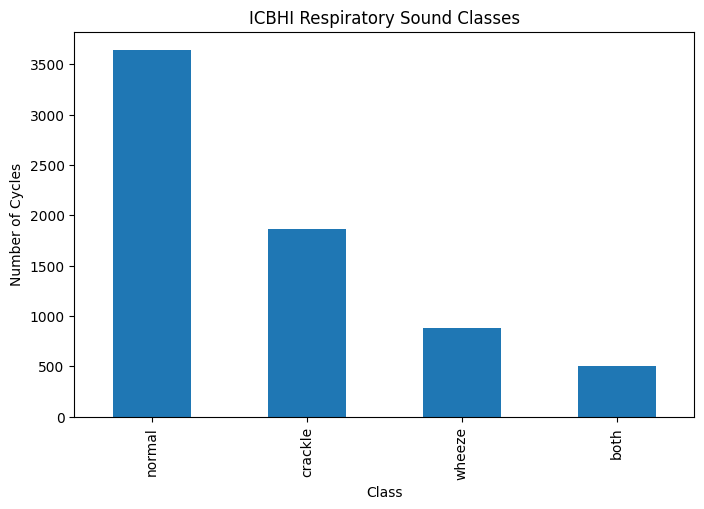

In [15]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("ICBHI Respiratory Sound Classes")
plt.xlabel("Class")
plt.ylabel("Number of Cycles")

plt.show()

### Cycle Duration Distribution

Respiratory cycles have variable durations.

Understanding this distribution is important because the resulting
spectrograms will initially have different time dimensions.

In [16]:
# how much one cycle lasts
cycles["duration"] = (
    cycles["end"] -
    cycles["start"]
)

cycles["duration"].describe()

count    6898.000000
mean        2.700509
std         1.172534
min         0.200000
25%         1.932000
50%         2.537000
75%         3.369000
max        16.163000
Name: duration, dtype: float64

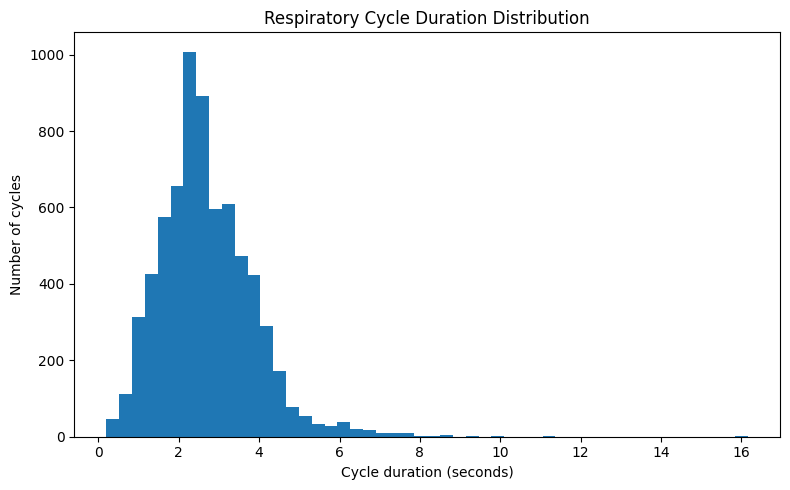

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    cycles["duration"],
    bins=50
)

plt.xlabel(
    "Cycle duration (seconds)"
)

plt.ylabel(
    "Number of cycles"
)

plt.title(
    "Respiratory Cycle Duration Distribution"
)

plt.tight_layout() # don't overlap
plt.show()

### Cycles per Patient

We examine how many respiratory cycles are contributed by each patient.

This is important for understanding patient-level imbalance.

In [19]:
patient_cycle_counts = (
    cycles
    .groupby("patient_id") # puts all cycles belonging to the same patient together:
    .size() # size() counts how many rows are in each group.
)

patient_cycle_counts.describe()

count    126.000000
mean      54.746032
std       67.686328
min        4.000000
25%       11.000000
50%       26.500000
75%       74.000000
max      507.000000
dtype: float64

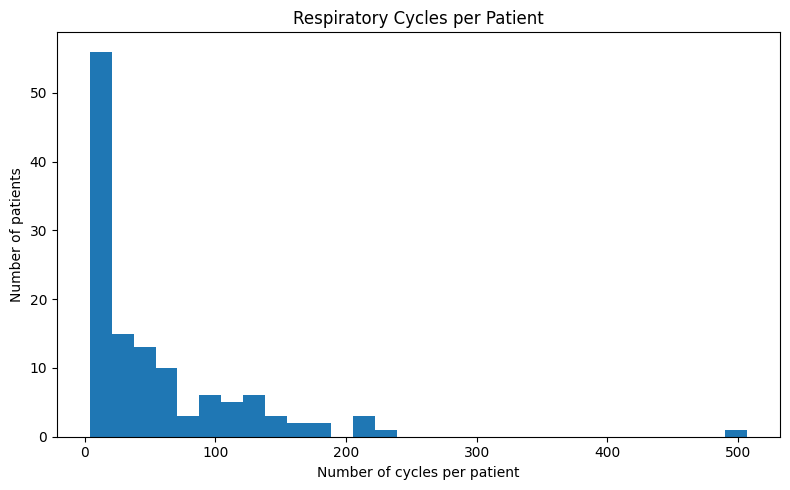

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    patient_cycle_counts,
    bins=30
)

plt.xlabel(
    "Number of cycles per patient"
)

plt.ylabel(
    "Number of patients"
)

plt.title(
    "Respiratory Cycles per Patient"
)

plt.tight_layout()
plt.show()

## **9. Patient-Level Train / Validation / Test Split**

### Important: Avoid Patient Leakage

All recordings and respiratory cycles belonging to the same patient
must remain in the same dataset split.

We therefore split patients first and then assign their cycles to
train, validation, or test.

This prevents the model from seeing recordings from the same patient
during both training and evaluation.

In [21]:
assert abs(
    TRAIN_RATIO +
    VAL_RATIO +
    TEST_RATIO - 1.0
) < 1e-6

print("Split ratios are valid.")

Split ratios are valid.


In [22]:
patients = np.array(
    cycles["patient_id"]
    .unique()
)

print(
    "Total patients:",
    len(patients)
)

Total patients: 126


In [23]:
rng = np.random.default_rng(
    SEED
)

rng.shuffle(
    patients # shuffle patient ids
)
print("Shuffled")

Shuffled


In [24]:
# Create patient splits
n_patients = len(patients)

n_train = int(
    TRAIN_RATIO * n_patients
)

n_val = int(
    VAL_RATIO * n_patients
)

train_patients = patients[
    :n_train
]

val_patients = patients[
    n_train:n_train + n_val
]

test_patients = patients[
    n_train + n_val:
]

print(
    "Train patients:",
    len(train_patients)
)

print(
    "Validation patients:",
    len(val_patients)
)

print(
    "Test patients:",
    len(test_patients)
)

Train patients: 88
Validation patients: 18
Test patients: 20


In [25]:
# Create split dataframes
# it creates a new DataFrame containing only the rows (cycles) from cycles whose patient_id belongs to train-val-test_patients.
train_df = cycles[
    cycles["patient_id"].isin( # For each patient ID, check whether it exists inside train_patients
        train_patients
    )
].copy() #  creates an independent copy of the selected data.

val_df = cycles[
    cycles["patient_id"].isin(
        val_patients
    )
].copy()

test_df = cycles[
    cycles["patient_id"].isin(
        test_patients
    )
].copy()


train_df.head()

,cycle_id,patient_id,recording_id,chest_location,acquisition_mode,equipment,audio_path,start,end,crackle,wheeze,label,duration
0,101_1b1_Al_sc_Meditron_0,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,0.579,0,0,normal,0.543
1,101_1b1_Al_sc_Meditron_1,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.579,2.450,0,0,normal,1.871
2,101_1b1_Al_sc_Meditron_2,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.450,3.893,0,0,normal,1.443
3,101_1b1_Al_sc_Meditron_3,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,3.893,5.793,0,0,normal,1.900
4,101_1b1_Al_sc_Meditron_4,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.793,7.521,0,0,normal,1.728


In [26]:
# Show split sizes
print(
    "Train cycles:",
    len(train_df)
)

print(
    "Validation cycles:",
    len(val_df)
)

print(
    "Test cycles:",
    len(test_df)
)

Train cycles: 4580
Validation cycles: 1133
Test cycles: 1185


## **10. Data Leakage Validation**

The patient sets must be mutually exclusive.

We explicitly verify:

- Train ∩ Validation = empty
- Train ∩ Test = empty
- Validation ∩ Test = empty

In [27]:
train_ids = set(
    train_df["patient_id"]
)

val_ids = set(
    val_df["patient_id"]
)

test_ids = set(
    test_df["patient_id"]
)

print(
    "Train ∩ Validation:",
    train_ids & val_ids # take intersection
)

print(
    "Train ∩ Test:",
    train_ids & test_ids
)

print(
    "Validation ∩ Test:",
    val_ids & test_ids
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [28]:
assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)

print(
    "✓ No patient overlap between splits"
)

✓ No patient overlap between splits


## **11. Examine Class Distribution After Splitting**

Patient-level splitting can result in different class proportions
between train, validation, and test sets.

We therefore inspect the class distribution of each split.

In [29]:
print("TRAIN")
print(
    train_df["label"].value_counts()
)

print("\nVALIDATION")
print(
    val_df["label"].value_counts()
)

print("\nTEST")
print(
    test_df["label"].value_counts()
)

TRAIN
label
normal     2270
crackle    1219
wheeze      716
both        375
Name: count, dtype: int64

VALIDATION
label
normal     663
crackle    347
wheeze      66
both        57
Name: count, dtype: int64

TEST
label
normal     709
crackle    298
wheeze     104
both        74
Name: count, dtype: int64


In [30]:
# Class proportions
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    print(f"\n{name}")

    print(
        (
            df["label"]
            .value_counts(
                normalize=True
            ) * 100
        ).round(2)
    )


Train
label
normal     49.56
crackle    26.62
wheeze     15.63
both        8.19
Name: proportion, dtype: float64

Validation
label
normal     58.52
crackle    30.63
wheeze      5.83
both        5.03
Name: proportion, dtype: float64

Test
label
normal     59.83
crackle    25.15
wheeze      8.78
both        6.24
Name: proportion, dtype: float64


In [31]:
#Save split manifests

train_df.to_csv(
    SPLIT_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    SPLIT_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    SPLIT_DIR / "test.csv",
    index=False
)

print("Split manifests saved.")

Split manifests saved.


## **12. Audio Inspection**

We now inspect the raw audio before applying preprocessing.

The original sampling rate is preserved when loading the WAV file
so that the preprocessing pipeline can explicitly control resampling.

In [ ]:
# sr = no. of samples per second
sample = train_df.iloc[0]

audio, sr = librosa.load( # librosa.load() reads an audio file and converts it into data that Python can work with usually numbers
    sample["audio_path"],
    sr=None, # keep sampling rate as original
    mono=True # use single channel
)

display(Audio(audio, rate=sr))

print(
    "File:",
    sample["audio_path"]
)

print(
    "Original sampling rate:",
    sr
)

print(
    "Number of samples:",
    len(audio)
)

print(
    "Duration:",
    len(audio) / sr,
    "seconds"
)

File: /kaggle/input/datasets/husninm/icbhi-2017-challenge/ICBHI_final_database/101_1b1_Al_sc_Meditron.wav
Original sampling rate: 44100
Number of samples: 882000
Duration: 20.0 seconds


## **13. Respiratory Cycle Extraction**

The annotation provides the start and end time of each respiratory
cycle in seconds.

These times are converted into sample indices and used to extract
the corresponding waveform segment.

In [33]:
def extract_cycle(audio,sr,start,end):

    start_sample = int(
        start * sr
    )

    end_sample = int(
        end * sr
    )

    return audio[
        start_sample:end_sample
    ]



cycle = extract_cycle(
    audio,
    sr,
    sample["start"],
    sample["end"]
)

print(
    "Cycle samples:",
    len(cycle)
)

print(
    "Cycle duration:",
    len(cycle) / sr,
    "seconds"
)

Cycle samples: 82512
Cycle duration: 1.8710204081632653 seconds


## Fixed-Length Cycle Representation

Respiratory cycles have different durations. To provide a consistent
input representation for the downstream AST pipeline, each cycle is
padded or truncated to a fixed duration of 8 seconds.

This produces a consistent waveform length before Log-Mel spectrogram
extraction.

In [34]:
def pad_or_truncate(signal, sr, target_duration):

    target_length = int(target_duration * sr)

    current_length = len(signal)

    if current_length == target_length:
        return signal

    if current_length > target_length:
        # center-crop: keep the middle portion, matches how you'd
        # want to preserve the cycle's core content over its edges
        start = (current_length - target_length) // 2
        return signal[start : start + target_length]

    # current_length < target_length: loop-pad
    # repeating the cycle's own content (not zero-padding) keeps every
    # sample acoustically meaningful — a zero-padded silence block would
    # dilute the crackle/wheeze energy, which is already the minority class
    n_repeats = int(np.ceil(target_length / current_length))

    tiled = np.tile(signal, n_repeats)

    return tiled[:target_length]



# test on the same sample cycle you've been using
padded_cycle = pad_or_truncate(
    cycle,
    TARGET_SR,
    TARGET_DURATION
)

print("Before padding:", len(cycle), "samples")
print("After padding:", len(padded_cycle), "samples")
print("Expected:", int(TARGET_DURATION * TARGET_SR), "samples")

Before padding: 82512 samples
After padding: 128000 samples
Expected: 128000 samples


## **14. Bandpass Filtering**

A Butterworth bandpass filter is applied to retain the selected
respiratory-sound frequency range.

### Configuration

- Low cutoff: 50 Hz
- High cutoff: 7900 Hz
- Filter order: 5

In [35]:
# filter the audio
def bandpass_filter(
    signal,
    sr,
    lowcut,
    highcut, # max frequency
    order=5
):
    # sos contains the mathematical coefficients describing the filter.
    sos = butter( # butter() designs a Butterworth filter
        order, # order tells us how sharply the filter changes from "keep" to "reduce."
        [lowcut, highcut],
        btype="bandpass", # allow a particular range of frequencies to pass
        fs=sr,
        output="sos"
    )

    return sosfiltfilt( # filter's the audio
        sos,
        signal
    )


# test one cycle
filtered_cycle = bandpass_filter(
    cycle,
    sr,
    LOWCUT,
    HIGHCUT
)

display(Audio(cycle, rate=sr))
print(
    "Filtered samples:",
    len(filtered_cycle)
)

Filtered samples: 82512


## **15. Resampling**

Audio recordings may have different sampling rates. All respiratory
cycles are resampled to a common target sampling rate of 16 kHz.

This ensures a consistent sampling rate for subsequent Log-Mel
spectrogram extraction and AST input preparation.

In [36]:
def resample_audio(signal,original_sr,target_sr):

    if original_sr == target_sr:
        return signal

    return librosa.resample(
        signal,
        orig_sr=original_sr,
        target_sr=target_sr
    )



# test the cycle
resampled_cycle = resample_audio(
    filtered_cycle,
    sr,
    TARGET_SR
)

print(
    "Original sampling rate:",
    sr
)

print(
    "Target sampling rate:",
    TARGET_SR
)

print(
    "New number of samples:",
    len(resampled_cycle)
)

Original sampling rate: 44100
Target sampling rate: 16000
New number of samples: 29937


## **16. Log-Mel Spectrogram Extraction**

The preprocessed respiratory waveform is converted into a 128-bin
Log-Mel spectrogram.

### Configuration

- Sampling rate: 16 kHz
- FFT size: 400 samples
- Hop length: 160 samples
- Mel bins: 128
- Frequency range: 50–7900 Hz

In [37]:
# converting the waveform into a 2D representation of frequency vs. time, called a log-Mel spectrogram.
def extract_logmel(signal,sr):

    mel = librosa.feature.melspectrogram( # gives us a 2-D matrix.
        y=signal,
        sr=sr,
        n_fft=N_FFT, # n_fft determines the size of the FFT(Fast Fourier Transform) window used for the frequency analysis,no. of sample for each analysis
        hop_length=HOP_LENGTH, # the number of samples between successive frames
        n_mels=N_MELS, # group frequencies into Mel frequency bands
        fmin=LOWCUT,
        fmax=HIGHCUT,
        power=2.0 # calculate a power spectrogram
    )

    log_mel = librosa.power_to_db( # converts the power values into decibels (dB)
        mel,
        ref=np.max # reference is the maximum power value in your particular mel spectrogram
    )

    return log_mel

# test the cycle
log_mel = extract_logmel(
    resampled_cycle,
    TARGET_SR
)

print(
    "Spectrogram shape:",
    log_mel.shape
)

# rows are Mel-frequency bands, and the columns are time frames

Spectrogram shape: (128, 188)


## **17. Visualize the Log-Mel Spectrogram**

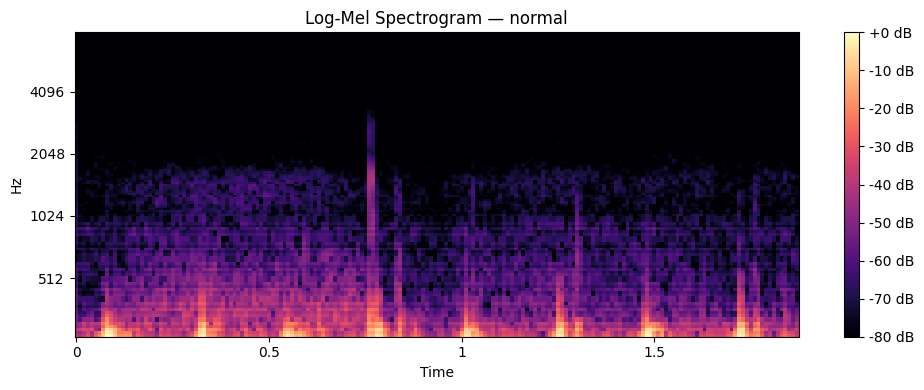

In [38]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    log_mel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=LOWCUT,
    fmax=HIGHCUT
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"Log-Mel Spectrogram — {sample['label']}"
)

plt.tight_layout()
plt.show()

## **18. Complete Preprocessing Pipeline**

Each respiratory cycle passes through the following preprocessing
pipeline:

Raw WAV
→ Respiratory-cycle extraction
→ Bandpass filtering
→ Resampling to 16 kHz
→ Fixed-length padding/truncation to 8 seconds
→ 128-bin Log-Mel spectrogram

In [39]:
def preprocess_cycle(audio_path,start,end):

    # Load original audio
    audio, sr = librosa.load(
        audio_path,
        sr=TARGET_SR,
        mono=True
    )

    # Extract annotated respiratory cycle
    cycle = extract_cycle(
        audio,
        sr,
        start,
        end
    )

    # Bandpass filter
    cycle = bandpass_filter(
        cycle,
        sr,
        LOWCUT,
        HIGHCUT
    )

    # Resample
    cycle = resample_audio(
        cycle,
        sr,
        TARGET_SR
    )

    # Pad / truncate to fixed duration  
    cycle = pad_or_truncate(
        cycle,
        TARGET_SR,
        TARGET_DURATION
    )

    # Log-Mel spectrogram
    log_mel = extract_logmel(
        cycle,
        TARGET_SR
    )

    return cycle, log_mel



# test the pipeline
test_waveform, test_spec = preprocess_cycle(
    sample["audio_path"],
    sample["start"],
    sample["end"]
)

print(
    "Waveform shape:",
    test_waveform.shape
)

print(
    "Spectrogram shape:",
    test_spec.shape
)

Waveform shape: (128000,)
Spectrogram shape: (128, 801)


## **19. Spectrogram Caching**

Preprocessed Log-Mel spectrograms are cached as `.npy` files so that
later model-training phases do not need to repeat the audio
preprocessing pipeline.

Existing cached files are reused when available.

In [40]:
def get_spectrogram_path(cycle_id): # get the path

    return (
        SPEC_DIR /
        f"{cycle_id}.npy" # .npy is NumPy's binary format for storing a NumPy array. It preserves the array's data and metadata needed to reconstruct it.
    )



# Cache one sample
spec_path = get_spectrogram_path(
    sample["cycle_id"]
)

np.save( # save the file and Convert the numbers in the spectrogram to 32-bit floating-point numbers.
    spec_path,
    test_spec.astype(
        np.float32
    )
)

print(
    "Saved:",
    spec_path
)



# Verify cache
loaded_spec = np.load(
    spec_path
)

print(
    "Loaded shape:",
    loaded_spec.shape
)

print(
    "Data type:",
    loaded_spec.dtype
)

Saved: /kaggle/working/icbhi_processed/spectrograms/101_1b1_Al_sc_Meditron_1.npy
Loaded shape: (128, 801)
Data type: float32


## **20. Process the Dataset**

We now apply the preprocessing pipeline to all respiratory cycles.

Already cached spectrograms are skipped so that rerunning the
notebook does not unnecessarily recompute existing features.

In [41]:
def process_dataframe(df):

    spectrogram_paths = []
    # one row at a time
    for _, row in tqdm(df.iterrows(), total=len(df),desc="Extracting spectrograms"):

        output_path = get_spectrogram_path(
            row["cycle_id"]
        )

        if not output_path.exists():# Check whether the file already exists

            _, spec = preprocess_cycle(
                row["audio_path"],
                row["start"],
                row["end"]
            )

            np.save(
                output_path,
                spec.astype(
                    np.float32
                )
            )

        spectrogram_paths.append(
            str(output_path)
        )

    return spectrogram_paths

In [42]:
# Process train
train_df["spectrogram_path"] = process_dataframe(train_df) # put the path in the dataframe in given column


# Process validation
val_df["spectrogram_path"] = process_dataframe(val_df)


# Process test
test_df["spectrogram_path"] = process_dataframe(test_df)

Extracting spectrograms:   0%|          | 0/4580 [00:00<?, ?it/s]

Extracting spectrograms:   0%|          | 0/1133 [00:00<?, ?it/s]

Extracting spectrograms:   0%|          | 0/1185 [00:00<?, ?it/s]

## **21. Save Final Split Manifests**

Each split now contains the metadata required to locate its cached
spectrograms.

The manifests will be used by the model-training notebook.

In [43]:
train_df.to_csv(
    SPLIT_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    SPLIT_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    SPLIT_DIR / "test.csv",
    index=False
)

print("Final manifests saved.")

Final manifests saved.


## **22. Final Data Quality Checks**

Before considering Phase 1 complete, we verify:

1. No patient leakage
2. No missing labels
3. No missing audio paths
4. No missing spectrogram paths
5. Spectrogram files exist
6. Dataset splits are non-empty

In [44]:
# Patient leakage

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("✓ Patient leakage check passed")

✓ Patient leakage check passed


In [45]:
for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    assert len(df) > 0

    assert df["label"].notna().all()

    assert df["audio_path"].notna().all()

    assert df["spectrogram_path"].notna().all()

    print(
        f"✓ {name}: basic checks passed"
    )

✓ train: basic checks passed
✓ validation: basic checks passed
✓ test: basic checks passed


In [46]:
# make sure path exits for every data point
for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    missing = sum(
        not Path(path).exists()
        for path in df["spectrogram_path"]
    )

    print(
        f"{name}: {missing} missing spectrogram files"
    )

    assert missing == 0


shapes = {np.load(p).shape for p in train_df["spectrogram_path"]}
assert len(shapes) == 1, f"Inconsistent spectrogram shapes found: {shapes}"
print("✓ All spectrograms have consistent shape:", shapes.pop())

train: 0 missing spectrogram files
validation: 0 missing spectrogram files
test: 0 missing spectrogram files
✓ All spectrograms have consistent shape: (128, 801)


## **23. Final Dataset Summary**

In [47]:
print("=" * 50)
print("ICBHI DATA PREPARATION SUMMARY")
print("=" * 50)

print(
    f"Patients: {cycles['patient_id'].nunique()}"
)

print(
    f"Recordings: {len(recordings)}"
)

print(
    f"Respiratory cycles: {len(cycles)}"
)

print()

print(
    f"Train cycles: {len(train_df)}"
)

print(
    f"Validation cycles: {len(val_df)}"
)

print(
    f"Test cycles: {len(test_df)}"
)

print()

print(
    "Patient leakage: NONE"
)

print(
    f"Target sampling rate: {TARGET_SR} Hz"
)

print(
    f"Bandpass: {LOWCUT}–{HIGHCUT} Hz"
)

print(
    f"Mel bins: {N_MELS}"
)

print(
    f"FFT size: {N_FFT}"
)

print(
    f"Hop length: {HOP_LENGTH}"
)

ICBHI DATA PREPARATION SUMMARY
Patients: 126
Recordings: 920
Respiratory cycles: 6898

Train cycles: 4580
Validation cycles: 1133
Test cycles: 1185

Patient leakage: NONE
Target sampling rate: 16000 Hz
Bandpass: 50–7900 Hz
Mel bins: 128
FFT size: 400
Hop length: 160


## **24. Output Structure**

The processed dataset has been organized as:

```text
icbhi_processed/
│
├── cycles.csv
│
├── splits/
│   ├── train.csv
│   ├── val.csv
│   └── test.csv
│
└── spectrograms/
    ├── <cycle_id>.npy
    ├── <cycle_id>.npy
    └── ...

## **25. Conclusion**

Phase 1 produced the processed ICBHI respiratory-sound dataset used by
the subsequent modeling experiments.

The preprocessing pipeline performs:

- Dataset validation
- Annotation parsing
- Four-class respiratory-cycle construction
- Patient-level train/validation/test splitting
- Patient-leakage validation
- Respiratory-cycle extraction
- Bandpass filtering
- Resampling to 16 kHz
- Fixed-length normalization to 8 seconds
- 128-bin Log-Mel spectrogram extraction
- Spectrogram caching
- Final dataset quality checks

The resulting split manifests and cached spectrograms are used by the
subsequent AST training experiments.